In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("/content/img.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

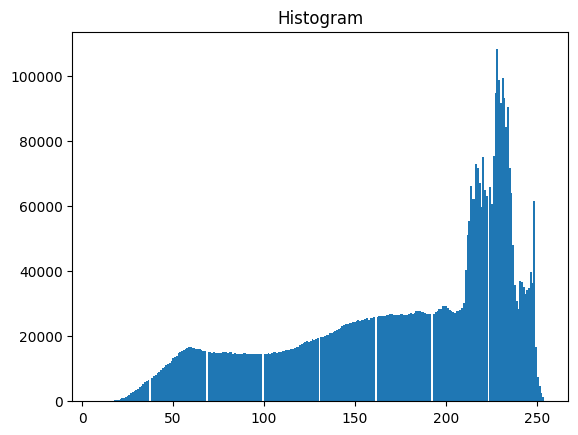

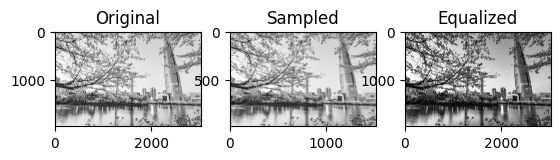

In [2]:
# Sampling (reduce resolution)
small = cv2.resize(gray, (0,0), fx=0.5, fy=0.5)

# Histogram
plt.hist(gray.ravel(), bins=256)
plt.title("Histogram")
plt.show()

# Histogram Equalization
equalized = cv2.equalizeHist(gray)

# Display
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(small, cmap='gray'); plt.title("Sampled")
plt.subplot(1,3,3); plt.imshow(equalized, cmap='gray'); plt.title("Equalized")
plt.show()

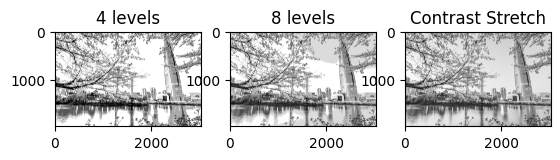

In [3]:
# Quantization (4 levels)
q4 = (gray // 64) * 64

# Quantization (8 levels)
q8 = (gray // 32) * 32

# Contrast Stretching
min_val = np.min(gray)
max_val = np.max(gray)

contrast = ((gray - min_val) / (max_val - min_val) * 255).astype(np.uint8)

# Display
plt.subplot(1,3,1); plt.imshow(q4, cmap='gray'); plt.title("4 levels")
plt.subplot(1,3,2); plt.imshow(q8, cmap='gray'); plt.title("8 levels")
plt.subplot(1,3,3); plt.imshow(contrast, cmap='gray'); plt.title("Contrast Stretch")
plt.show()

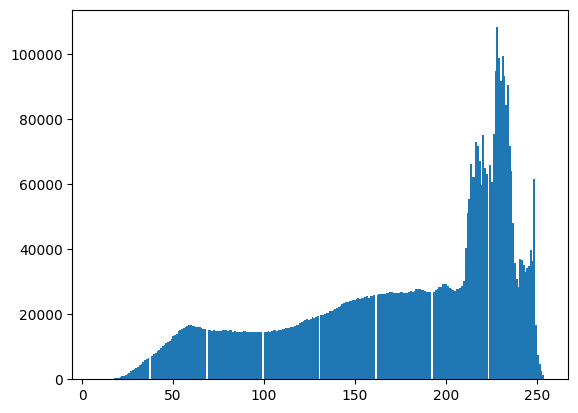

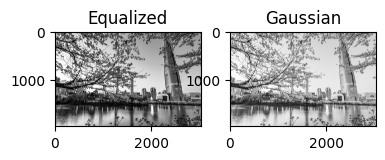

In [4]:
# Histogram
plt.hist(gray.ravel(), bins=256)
plt.show()

# Equalization
equalized = cv2.equalizeHist(gray)

# Gaussian Filter
gaussian = cv2.GaussianBlur(gray, (5,5), 0)

# Display
plt.subplot(1,3,1); plt.imshow(equalized, cmap='gray'); plt.title("Equalized")
plt.subplot(1,3,2); plt.imshow(gaussian, cmap='gray'); plt.title("Gaussian")
plt.show()

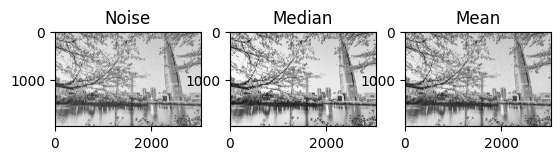

In [5]:
# Add Salt & Pepper noise
noise = gray.copy()
prob = 0.05

rnd = np.random.rand(*gray.shape)
noise[rnd < prob] = 0
noise[rnd > 1 - prob] = 255

# Median filter
median = cv2.medianBlur(noise, 5)

# Mean filter
mean = cv2.blur(noise, (5,5))

# Display
plt.subplot(1,3,1); plt.imshow(noise, cmap='gray'); plt.title("Noise")
plt.subplot(1,3,2); plt.imshow(median, cmap='gray'); plt.title("Median")
plt.subplot(1,3,3); plt.imshow(mean, cmap='gray'); plt.title("Mean")
plt.show()

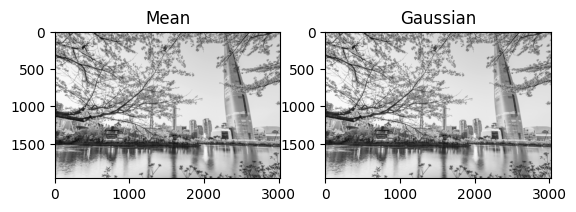

In [6]:
# Mean filter
mean = cv2.blur(gray, (5,5))

# Gaussian filter
gaussian = cv2.GaussianBlur(gray, (5,5), 0)

# Display
plt.subplot(1,2,1); plt.imshow(mean, cmap='gray'); plt.title("Mean")
plt.subplot(1,2,2); plt.imshow(gaussian, cmap='gray'); plt.title("Gaussian")
plt.show()

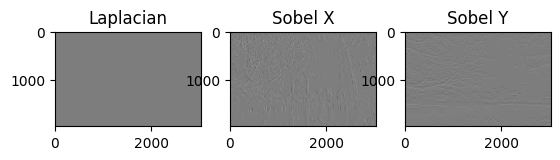

In [7]:
# Laplacian
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Sobel
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)

# Display
plt.subplot(1,3,1); plt.imshow(laplacian, cmap='gray'); plt.title("Laplacian")
plt.subplot(1,3,2); plt.imshow(sobelx, cmap='gray'); plt.title("Sobel X")
plt.subplot(1,3,3); plt.imshow(sobely, cmap='gray'); plt.title("Sobel Y")
plt.show()

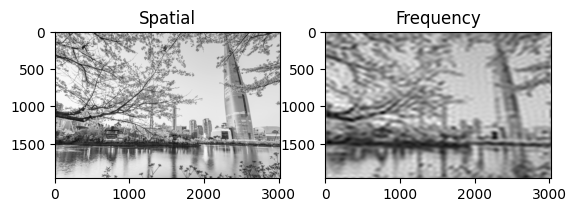

In [8]:
# Spatial (Gaussian)
gaussian = cv2.GaussianBlur(gray, (5,5), 0)

# Frequency domain (Low Pass)
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)

rows, cols = gray.shape
crow, ccol = rows//2 , cols//2

mask = np.zeros((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

fshift = fshift * mask
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Display
plt.subplot(1,2,1); plt.imshow(gaussian, cmap='gray'); plt.title("Spatial")
plt.subplot(1,2,2); plt.imshow(img_back, cmap='gray'); plt.title("Frequency")
plt.show()

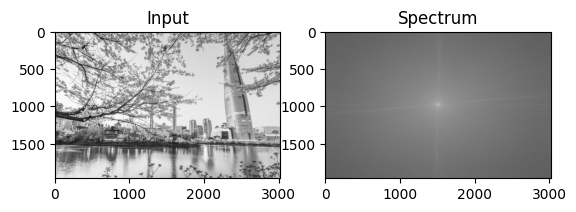

In [9]:
# FFT
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)

# Magnitude spectrum
magnitude = 20 * np.log(np.abs(fshift))

# Display
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title("Input")
plt.subplot(1,2,2); plt.imshow(magnitude, cmap='gray'); plt.title("Spectrum")
plt.show()

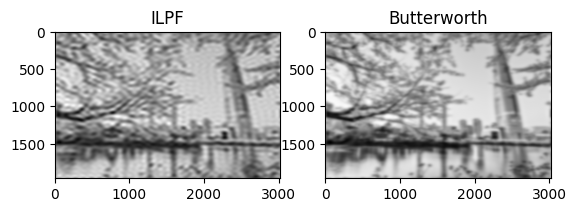

In [10]:
rows, cols = gray.shape
crow, ccol = rows//2 , cols//2

# Ideal LPF
mask = np.zeros((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)
ilpf = fshift * mask

# Butterworth LPF
D0 = 30
n = 2
butter = np.zeros((rows, cols))
for u in range(rows):
    for v in range(cols):
        D = np.sqrt((u-crow)**2 + (v-ccol)**2)
        butter[u,v] = 1 / (1 + (D/D0)**(2*n))

butter_f = fshift * butter

# Inverse FFT
def inverse(img):
    img = np.fft.ifftshift(img)
    img = np.fft.ifft2(img)
    return np.abs(img)

ilpf_img = inverse(ilpf)
butter_img = inverse(butter_f)

# Display
plt.subplot(1,2,1); plt.imshow(ilpf_img, cmap='gray'); plt.title("ILPF")
plt.subplot(1,2,2); plt.imshow(butter_img, cmap='gray'); plt.title("Butterworth")
plt.show()

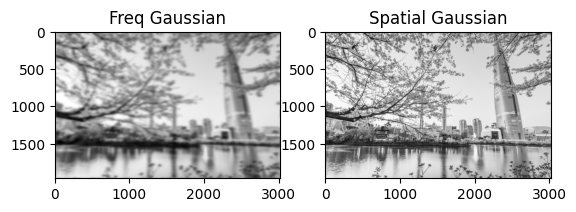

In [11]:
rows, cols = gray.shape
crow, ccol = rows//2 , cols//2

# Gaussian LPF
D0 = 30
gauss = np.zeros((rows, cols))

for u in range(rows):
    for v in range(cols):
        D = (u-crow)**2 + (v-ccol)**2
        gauss[u,v] = np.exp(-D / (2*(D0**2)))

f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)
gauss_f = fshift * gauss

# Inverse
img_back = np.fft.ifft2(np.fft.ifftshift(gauss_f))
img_back = np.abs(img_back)

# Spatial Gaussian
spatial = cv2.GaussianBlur(gray, (5,5), 0)

# Display
plt.subplot(1,2,1); plt.imshow(img_back, cmap='gray'); plt.title("Freq Gaussian")
plt.subplot(1,2,2); plt.imshow(spatial, cmap='gray'); plt.title("Spatial Gaussian")
plt.show()

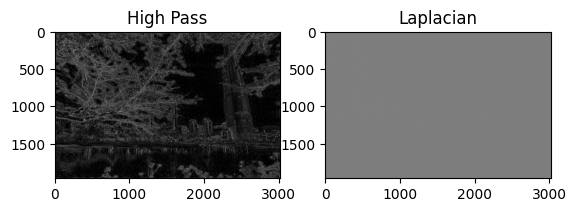

In [12]:
# FFT
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)

rows, cols = gray.shape
crow, ccol = rows//2 , cols//2

# High Pass Filter mask
mask = np.ones((rows, cols), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 0

# Apply HPF
hpf = fshift * mask
img_back = np.fft.ifft2(np.fft.ifftshift(hpf))
img_back = np.abs(img_back)

# Laplacian
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Display
plt.subplot(1,2,1); plt.imshow(img_back, cmap='gray'); plt.title("High Pass")
plt.subplot(1,2,2); plt.imshow(laplacian, cmap='gray'); plt.title("Laplacian")
plt.show()

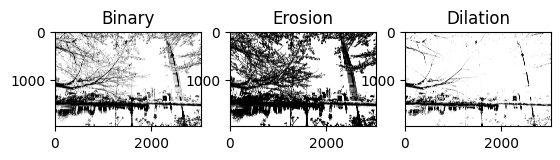

In [13]:
# Convert to binary
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)

# Erosion
erosion = cv2.erode(binary, kernel, iterations=1)

# Dilation
dilation = cv2.dilate(binary, kernel, iterations=1)

# Display
plt.subplot(1,3,1); plt.imshow(binary, cmap='gray'); plt.title("Binary")
plt.subplot(1,3,2); plt.imshow(erosion, cmap='gray'); plt.title("Erosion")
plt.subplot(1,3,3); plt.imshow(dilation, cmap='gray'); plt.title("Dilation")
plt.show()

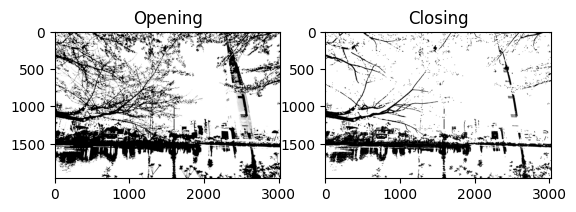

In [14]:
kernel = np.ones((5,5), np.uint8)

# Opening (erosion → dilation)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# Closing (dilation → erosion)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

# Display
plt.subplot(1,2,1); plt.imshow(opening, cmap='gray'); plt.title("Opening")
plt.subplot(1,2,2); plt.imshow(closing, cmap='gray'); plt.title("Closing")
plt.show()

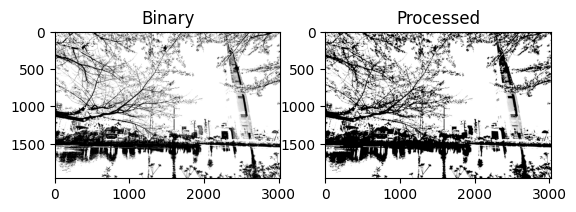

In [15]:
# Binary conversion
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)

# Opening (remove noise)
processed = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# Display
plt.subplot(1,2,1); plt.imshow(binary, cmap='gray'); plt.title("Binary")
plt.subplot(1,2,2); plt.imshow(processed, cmap='gray'); plt.title("Processed")
plt.show()

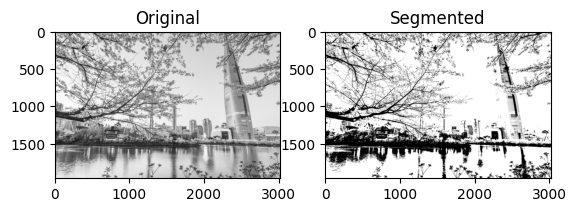

In [16]:
# Thresholding
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Display
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(thresh, cmap='gray'); plt.title("Segmented")
plt.show()

Number of objects: 5777


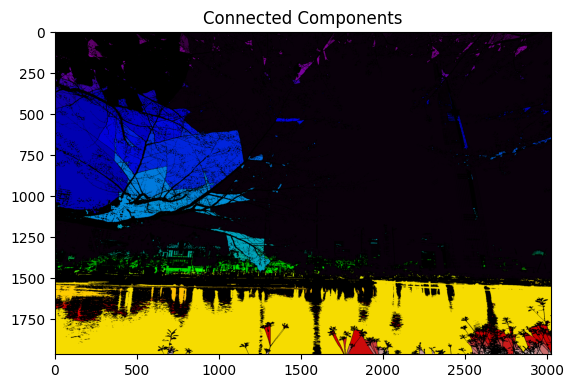

In [17]:
# Threshold
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Connected Components
num_labels, labels = cv2.connectedComponents(thresh)

print("Number of objects:", num_labels - 1)

# Display labeled image
plt.imshow(labels, cmap='nipy_spectral')
plt.title("Connected Components")
plt.show()

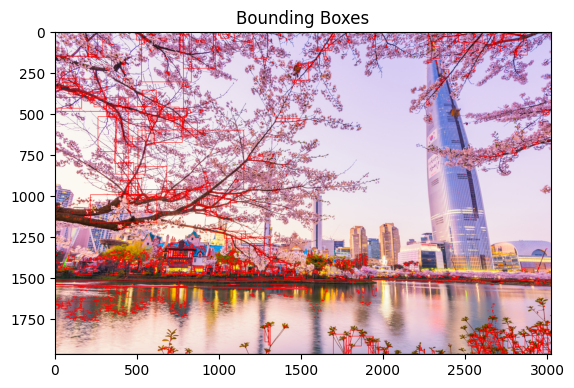

In [18]:
# Threshold
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_copy = img.copy()

# Draw bounding boxes
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_copy, (x,y), (x+w, y+h), (255,0,0), 2)

# Display
plt.imshow(img_copy)
plt.title("Bounding Boxes")
plt.show()

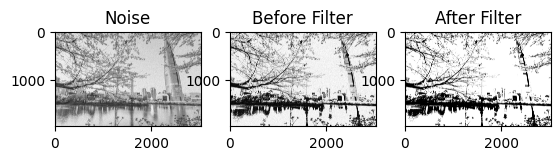

In [19]:
# Add noise
noise = gray.copy()
prob = 0.05
rnd = np.random.rand(*gray.shape)
noise[rnd < prob] = 0
noise[rnd > 1 - prob] = 255

# Segmentation (before filtering)
_, seg1 = cv2.threshold(noise, 127, 255, cv2.THRESH_BINARY)

# Filtering
filtered = cv2.medianBlur(noise, 5)

# Segmentation (after filtering)
_, seg2 = cv2.threshold(filtered, 127, 255, cv2.THRESH_BINARY)

# Display
plt.subplot(1,3,1); plt.imshow(noise, cmap='gray'); plt.title("Noise")
plt.subplot(1,3,2); plt.imshow(seg1, cmap='gray'); plt.title("Before Filter")
plt.subplot(1,3,3); plt.imshow(seg2, cmap='gray'); plt.title("After Filter")
plt.show()

Objects after cleaning: 2164


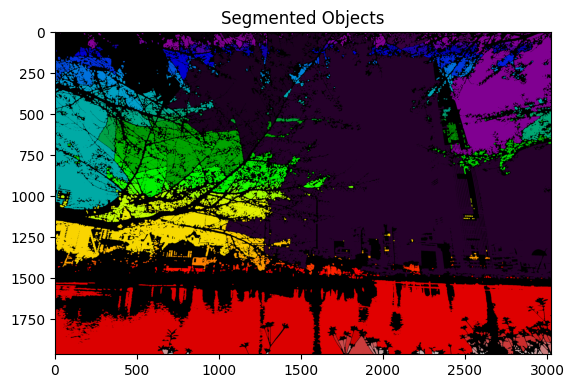

In [20]:
# Threshold
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

kernel = np.ones((5,5), np.uint8)

# Morphology
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Segmentation
num_labels, labels = cv2.connectedComponents(clean)

print("Objects after cleaning:", num_labels - 1)

# Display
plt.imshow(labels, cmap='nipy_spectral')
plt.title("Segmented Objects")
plt.show()

In [21]:
from skimage.feature import graycomatrix, graycoprops

# Convert to 8-bit if needed
img_gray = gray.astype(np.uint8)

# GLCM
glcm = graycomatrix(img_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

# Features
contrast = graycoprops(glcm, 'contrast')[0,0]
energy = graycoprops(glcm, 'energy')[0,0]
homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
correlation = graycoprops(glcm, 'correlation')[0,0]

print("Contrast:", contrast)
print("Energy:", energy)
print("Homogeneity:", homogeneity)
print("Correlation:", correlation)

Contrast: 416.8548157270835
Energy: 0.0451665880115388
Homogeneity: 0.38467493376799006
Correlation: 0.9417057783941976


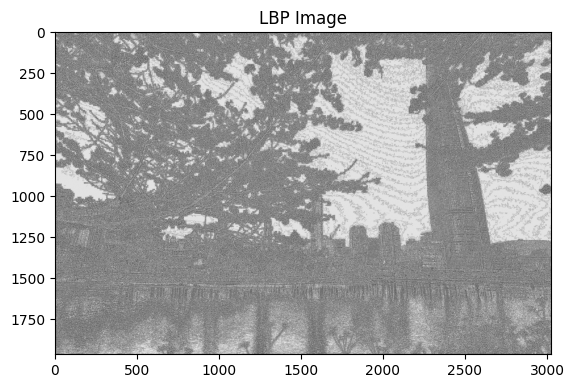

In [22]:
from skimage.feature import local_binary_pattern

# LBP
lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')

# Display
plt.imshow(lbp, cmap='gray')
plt.title("LBP Image")
plt.show()

In [23]:
# LBP histogram
lbp = local_binary_pattern(gray, 8, 1, method='uniform')
lbp_hist, _ = np.histogram(lbp.ravel(), bins=256)

# GLCM
from skimage.feature import graycomatrix, graycoprops
glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)

contrast = graycoprops(glcm, 'contrast')[0,0]

print("GLCM Contrast:", contrast)
print("LBP Histogram Sum:", np.sum(lbp_hist))

GLCM Contrast: 416.8548157270835
LBP Histogram Sum: 5939136


In [24]:
from sklearn.decomposition import PCA

# Flatten image
flat = gray.reshape(-1, 1)

# PCA
pca = PCA(n_components=1)
reduced = pca.fit_transform(flat)

print("Reduced shape:", reduced.shape)

Reduced shape: (5939136, 1)


In [25]:
# Filtering
filtered = cv2.GaussianBlur(gray, (5,5), 0)

# GLCM
from skimage.feature import graycomatrix, graycoprops
glcm = graycomatrix(filtered, [1], [0], 256, symmetric=True, normed=True)

contrast = graycoprops(glcm, 'contrast')[0,0]

print("Contrast after preprocessing:", contrast)

Contrast after preprocessing: 92.05852651733854


In [26]:
# Preprocessing
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Segmentation
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

# Feature extraction (GLCM)
from skimage.feature import graycomatrix, graycoprops
glcm = graycomatrix(thresh, [1], [0], 256, symmetric=True, normed=True)
energy = graycoprops(glcm, 'energy')[0,0]

print("Energy feature:", energy)

Energy feature: 0.7892341709881551


In [27]:
# Downsample
small = cv2.resize(gray, (0,0), fx=0.5, fy=0.5)

# Feature extraction
from skimage.feature import graycomatrix, graycoprops
glcm = graycomatrix(small, [1], [0], 256, symmetric=True, normed=True)

contrast = graycoprops(glcm, 'contrast')[0,0]

print("Contrast (low resolution):", contrast)

Contrast (low resolution): 658.8830800875049


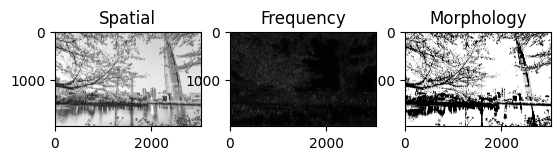

In [28]:
# Spatial
spatial = cv2.GaussianBlur(gray, (5,5), 0)

# Frequency
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)
fshift[30:-30, 30:-30] = 0
freq = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift)))

# Morphology
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
kernel = np.ones((5,5), np.uint8)
morph = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Display
plt.subplot(1,3,1); plt.imshow(spatial, cmap='gray'); plt.title("Spatial")
plt.subplot(1,3,2); plt.imshow(freq, cmap='gray'); plt.title("Frequency")
plt.subplot(1,3,3); plt.imshow(morph, cmap='gray'); plt.title("Morphology")
plt.show()

In [29]:
# Noise removal
denoise = cv2.medianBlur(gray, 5)

# Segmentation
_, thresh = cv2.threshold(denoise, 127, 255, cv2.THRESH_BINARY)

# Feature extraction
from skimage.feature import graycomatrix, graycoprops
glcm = graycomatrix(thresh, [1], [0], 256, symmetric=True, normed=True)
contrast = graycoprops(glcm, 'contrast')[0,0]

# PCA
from sklearn.decomposition import PCA
flat = thresh.reshape(-1,1)
pca = PCA(n_components=1)
reduced = pca.fit_transform(flat)

print("Contrast:", contrast)
print("Reduced shape:", reduced.shape)

Contrast: 1784.121720745163
Reduced shape: (5939136, 1)


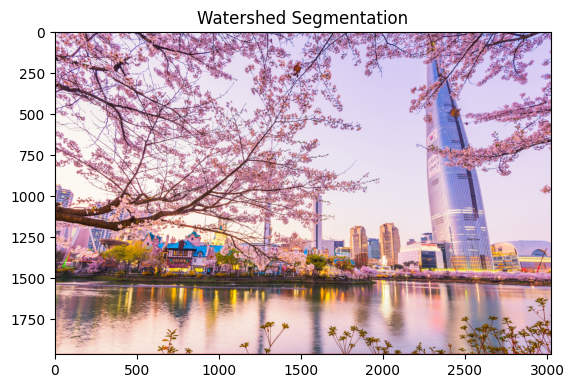

In [30]:
# Convert to gray
gray_w = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Threshold
_, thresh = cv2.threshold(gray_w, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Noise removal
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

# Sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Distance transform
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.7*dist.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labeling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 0] = 0

# Watershed
markers = cv2.watershed(img, markers)
img[markers == -1] = [255,0,0]

plt.imshow(img)
plt.title("Watershed Segmentation")
plt.show()

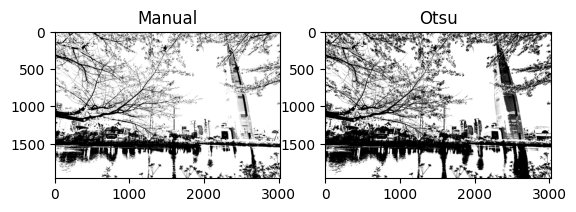

In [31]:
# Manual threshold
_, manual = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Otsu threshold
_, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display
plt.subplot(1,2,1); plt.imshow(manual, cmap='gray'); plt.title("Manual")
plt.subplot(1,2,2); plt.imshow(otsu, cmap='gray'); plt.title("Otsu")
plt.show()